In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import ode
from qutip import *

In [2]:
g_tx = 0
k_tx= 0

g_rx = 0
k_rx= 0

In [3]:
def h_tx():
    matrix = np.array(
            [[0, g_tx, 0, 0],
            [g_tx.conj(), 1j*k_tx/2, 0, 0],
            [0, 0, 0, 0],
            [0, 0, 0, 0]]
            )
    return matrix

def h_rx():
    matrix = np.array(
            [[0, g_rx, 0, 0],
            [g_rx.conj(), 1j*k_rx/2, 0, 0],
            [0, 0, 0, 0],
            [0, 0, 0, 0]]
            )
    return matrix

def h_comm():
    matrix = np.array(
            [[0, g_rx, 0, 0],
            [g_rx.conj(), 1j*k_rx/2, 0, 0],
            [0, 0, 0, 0],
            [0, 0, 0, 0]]
            )
    return matrix

def h_total():
    return h_tx() + h_rx() + h_total

In [4]:
def dissipation(operator, rho):
    first = np.dot(np.dot(operator, rho), operator.conj()) 
    second = (np.dot(np.dot(operator.conj(), operator), rho) + np.dot(rho, np.dot(operator.conj(), operator)))/2
    return first - second

In [5]:
def right_part(t, rho):
    heis = 1j * (np.dot(h_total(), rho) - np.dot(rho, h_total()))
    diss = dissipation()
    decay = 0
    return heis + diss + decay


In [6]:
H = 2 * np.pi * 0.1 * sigmax()
psi0 = basis(2, 0)
times = np.linspace(0, 10, 100)
result = mesolve(H, psi0, times, [np.sqrt(0.05) * sigmax()], [sigmaz(), sigmay()])

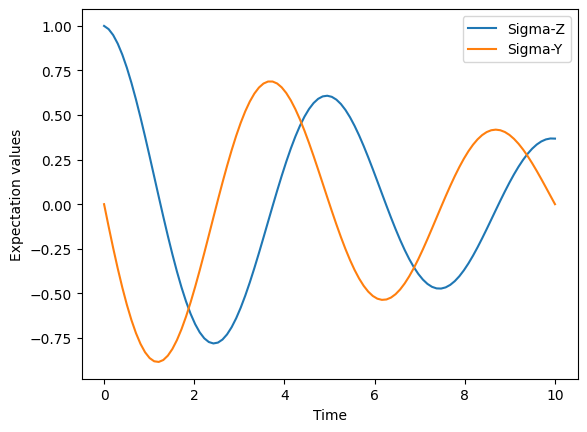

In [7]:
fig, ax = plt.subplots()
ax.plot(result.times, result.expect[0])
ax.plot(result.times, result.expect[1])
ax.set_xlabel('Time')
ax.set_ylabel('Expectation values')
ax.legend(("Sigma-Z", "Sigma-Y"))
plt.show()

In [8]:
times = np.linspace(0, 10, 200)
psi0 = tensor(fock(2,0), fock(10, 5))
a  = tensor(qeye(2), destroy(10))
sm = tensor(destroy(2), qeye(10))
H = 2 * np.pi * a.dag() * a + 2 * np.pi * sm.dag() * sm + 2 * np.pi * 0.25 * (sm * a.dag() + sm.dag() * a)
result = mesolve(H, psi0, times, [np.sqrt(0.1)*a], [a.dag()*a, sm.dag()*sm])

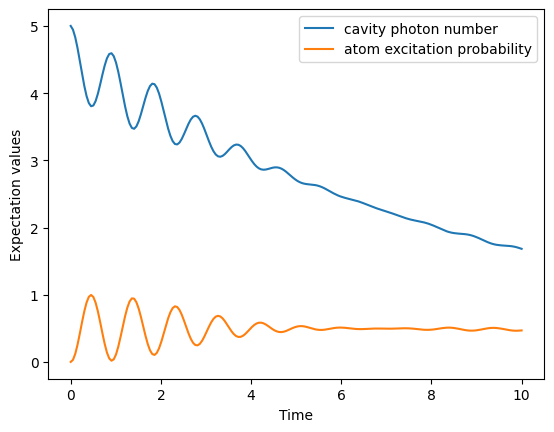

In [9]:
plt.figure()
plt.plot(times, result.expect[0])
plt.plot(times, result.expect[1])
plt.xlabel('Time')
plt.ylabel('Expectation values')
plt.legend(("cavity photon number", "atom excitation probability"))
plt.show()

from Miyamura-san

In [10]:
import qutip as qt
import matplotlib.pyplot as plt
import numpy as np

In [11]:
n_cutoff_A = 5
n_cutoff_B = 5
n_cutoff_rA = 4
n_cutoff_rB = 4


b_A = qt.tensor(qt.destroy(n_cutoff_A), qt.qeye(n_cutoff_rA), qt.qeye(n_cutoff_rB), qt.qeye(n_cutoff_B))
b_B = qt.tensor(qt.qeye(n_cutoff_A), qt.qeye(n_cutoff_rA), qt.qeye(n_cutoff_rB), qt.destroy(n_cutoff_B))
a_A = qt.tensor(qt.qeye(n_cutoff_A), qt.destroy(n_cutoff_rA), qt.qeye(n_cutoff_rB), qt.qeye(n_cutoff_B))
a_B = qt.tensor(qt.qeye(n_cutoff_A), qt.qeye(n_cutoff_rA), qt.destroy(n_cutoff_rB), qt.qeye(n_cutoff_B))

f0_A = qt.tensor(qt.basis(n_cutoff_A, 2), qt.basis(n_cutoff_rA, 0), qt.basis(n_cutoff_rB, 0), qt.basis(n_cutoff_B, 0))
g1_A = qt.tensor(qt.basis(n_cutoff_A, 0), qt.basis(n_cutoff_rA, 1), qt.basis(n_cutoff_rB, 0), qt.basis(n_cutoff_B, 0))
f0_B = qt.tensor(qt.basis(n_cutoff_A, 0), qt.basis(n_cutoff_rA, 0), qt.basis(n_cutoff_rB, 0), qt.basis(n_cutoff_B, 2))
g1_B = qt.tensor(qt.basis(n_cutoff_A, 0), qt.basis(n_cutoff_rA, 0), qt.basis(n_cutoff_rB, 1), qt.basis(n_cutoff_B, 0))
# e0_A = qt.tensor(qt.basis(n_cutoff_A, 1), qt.basis(n_cutoff_rA, 0), qt.basis(n_cutoff_rB, 0), qt.basis(n_cutoff_B, 0))

alpha_A = -0.3 * 2 * np.pi
chi_A = -0.006 * 2 * np.pi
alpha_B = -0.3 * 2 * np.pi
chi_B = -0.006 * 2 * np.pi
eta = 0.5
kappa_A = 0.02 * 2 * np.pi
kappa_B = 0.02 * 2 * np.pi

In [12]:
H_fogi_A = (
    -alpha_A / 2 * b_A.dag()*b_A + alpha_A * b_A.dag()*b_A.dag()*b_A*b_A / 2
    # +chi_A*a_A.dag()*a_A*b_A.dag()*b_A
)

H_fogi_B = (
    -alpha_B / 2 * b_B.dag()*b_B + alpha_B * b_B.dag()*b_B.dag()*b_B*b_B / 2
    # +chi_B*a_B.dag()*a_B*b_B.dag()*b_B
)

H_c = 1j * np.sqrt(eta) * (np.sqrt(kappa_A*kappa_B)/2) * (a_A.dag()*a_B - a_A*a_B.dag())

H_d_A = -a_A.dag()*b_A*b_A/np.sqrt(2) - a_A*b_A.dag()*b_A.dag()/np.sqrt(2)
H_d_B = -a_B.dag()*b_B*b_B/np.sqrt(2) - a_B*b_B.dag()*b_B.dag()/np.sqrt(2) 

def g_eff(t, args,):
    kappa = min(kappa_A, kappa_B)
    return kappa / (2 * np.cosh(kappa*(t-args["center"])/2))

H = [H_fogi_A+H_fogi_B+H_c, [H_d_A, g_eff], [H_d_B, g_eff],]

d:\K_Sunada\.venv\lib\site-packages\qutip\solver\options.py:16: FutureWarning: Dedicated options class are no longer needed, options should be passed as dict to solvers.
  warnings.warn(
d:\K_Sunada\.venv\lib\site-packages\qutip\solver\solver_base.py:459: FutureWarning: "progress_bar" is now included in options:
 Use `options={"progress_bar": False / True / "tqdm" / "enhanced"}`
  warnings.warn(


10.0%. Run time:  29.78s. Est. time left: 00:00:04:28
20.0%. Run time:  62.85s. Est. time left: 00:00:04:11
30.0%. Run time:  98.86s. Est. time left: 00:00:03:50
40.0%. Run time: 131.12s. Est. time left: 00:00:03:16
50.0%. Run time: 161.25s. Est. time left: 00:00:02:41
60.0%. Run time: 183.59s. Est. time left: 00:00:02:02
70.0%. Run time: 203.94s. Est. time left: 00:00:01:27
80.0%. Run time: 224.42s. Est. time left: 00:00:00:56
90.0%. Run time: 244.74s. Est. time left: 00:00:00:27
100.0%. Run time: 265.55s. Est. time left: 00:00:00:00
Total run time: 265.56s


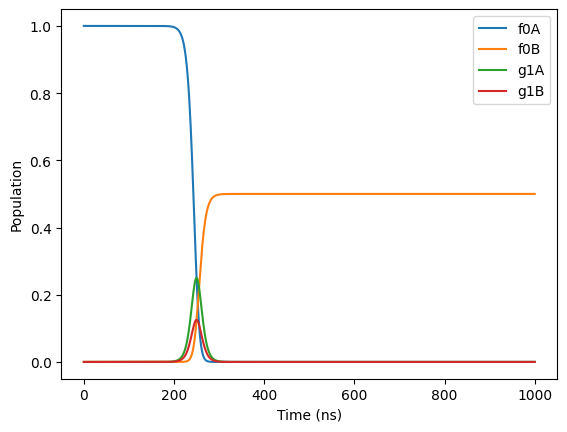

In [13]:
c_ops = [np.sqrt(kappa_A*eta)*a_A + np.sqrt(kappa_B)*a_B, np.sqrt(kappa_A*(1-eta))*a_A]
e_ops = [f0_A.proj(), f0_B.proj(), g1_A.proj(), g1_B.proj()]
e_labels = ["f0A", "f0B", "g1A", "g1B"]
options = qt.Options(atol=1e-9, rtol=1e-9, nsteps=1000, max_step=0.1, store_states=False)
psi0 = f0_A
t = np.linspace(0, 1000, 1001)

result = qt.mesolve(
    H, psi0, t, c_ops, e_ops, args={"center":250}, options=options, progress_bar=True
)

fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)
for i, l in enumerate(e_labels):
    ax.plot(t, np.abs(result.expect[i]), label=l)
ax.legend()
ax.set_xlabel("Time (ns)") ;ax.set_ylabel("Population")
plt.show()

In [14]:
def g_eff(t, args,):
    kappa = min(kappa_A, kappa_B)
    return kappa / (2 * np.cosh(kappa*(t-args["center"])/2))